# Учимся работе с данными - от загрузки до моделирования

## Часть 1. EDA
### Загрузка данных

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, roc_auc_score

## Загрузка датасета

In [3]:
df = pd.read_csv("data.csv")

df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


## Первичный анализ данных

In [4]:
df.shape

(569, 33)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    str    
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             569 non-null

In [6]:
df.describe()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,0.0
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,NaN
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,NaN
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,NaN
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,NaN
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,NaN
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,NaN
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,NaN


## Очистка данных

In [7]:
df = df.drop(columns=["id", "Unnamed: 32"])

## Кодирование целевой переменной 

In [8]:
df["diagnosis"] = df["diagnosis"].map({"M": 1, "B": 0})

## Проверка 

In [9]:
df["diagnosis"].value_counts()

diagnosis
0    357
1    212
Name: count, dtype: int64

In [10]:
df.isnull().sum()

diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64

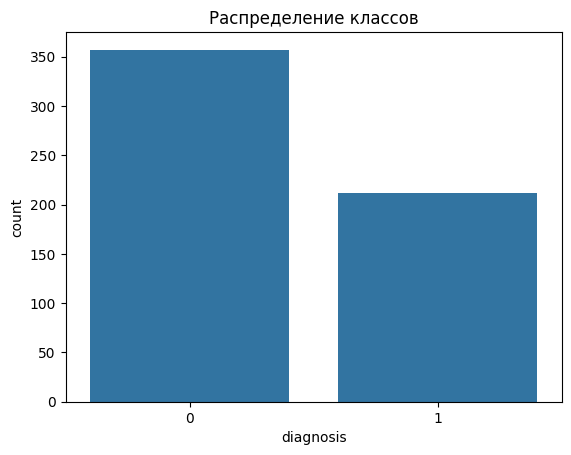

In [11]:
sns.countplot(x="diagnosis", data=df)
plt.title("Распределение классов")
plt.show()

## Гистограммы 

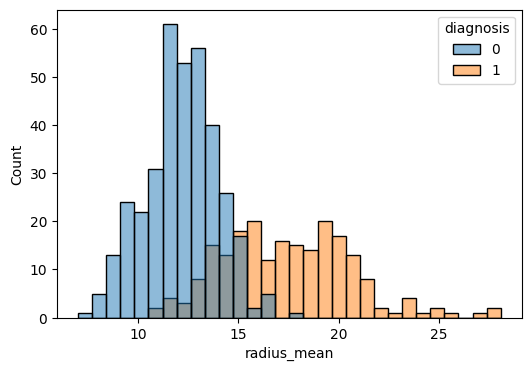

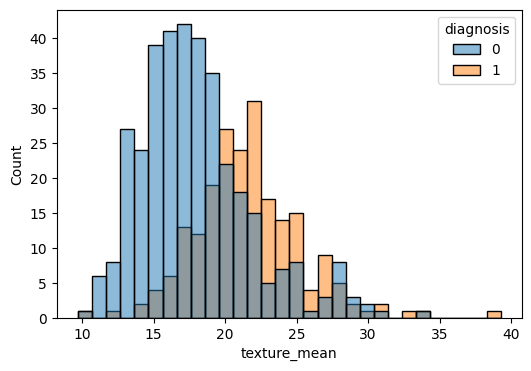

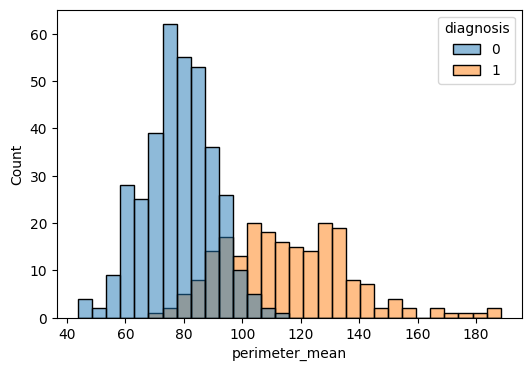

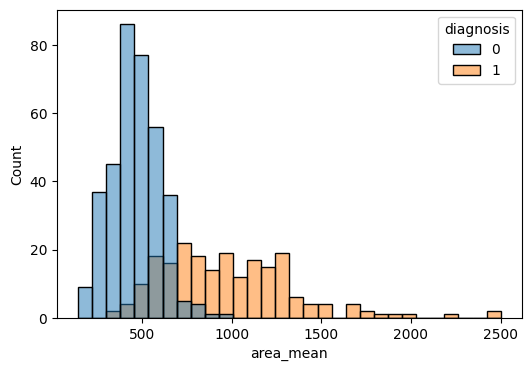

In [12]:
features = ["radius_mean","texture_mean","perimeter_mean","area_mean"]

for col in features:
    plt.figure(figsize=(6,4))
    sns.histplot(data=df, x=col, hue="diagnosis", bins=30)
    plt.show()

## Heatmap корреляций 

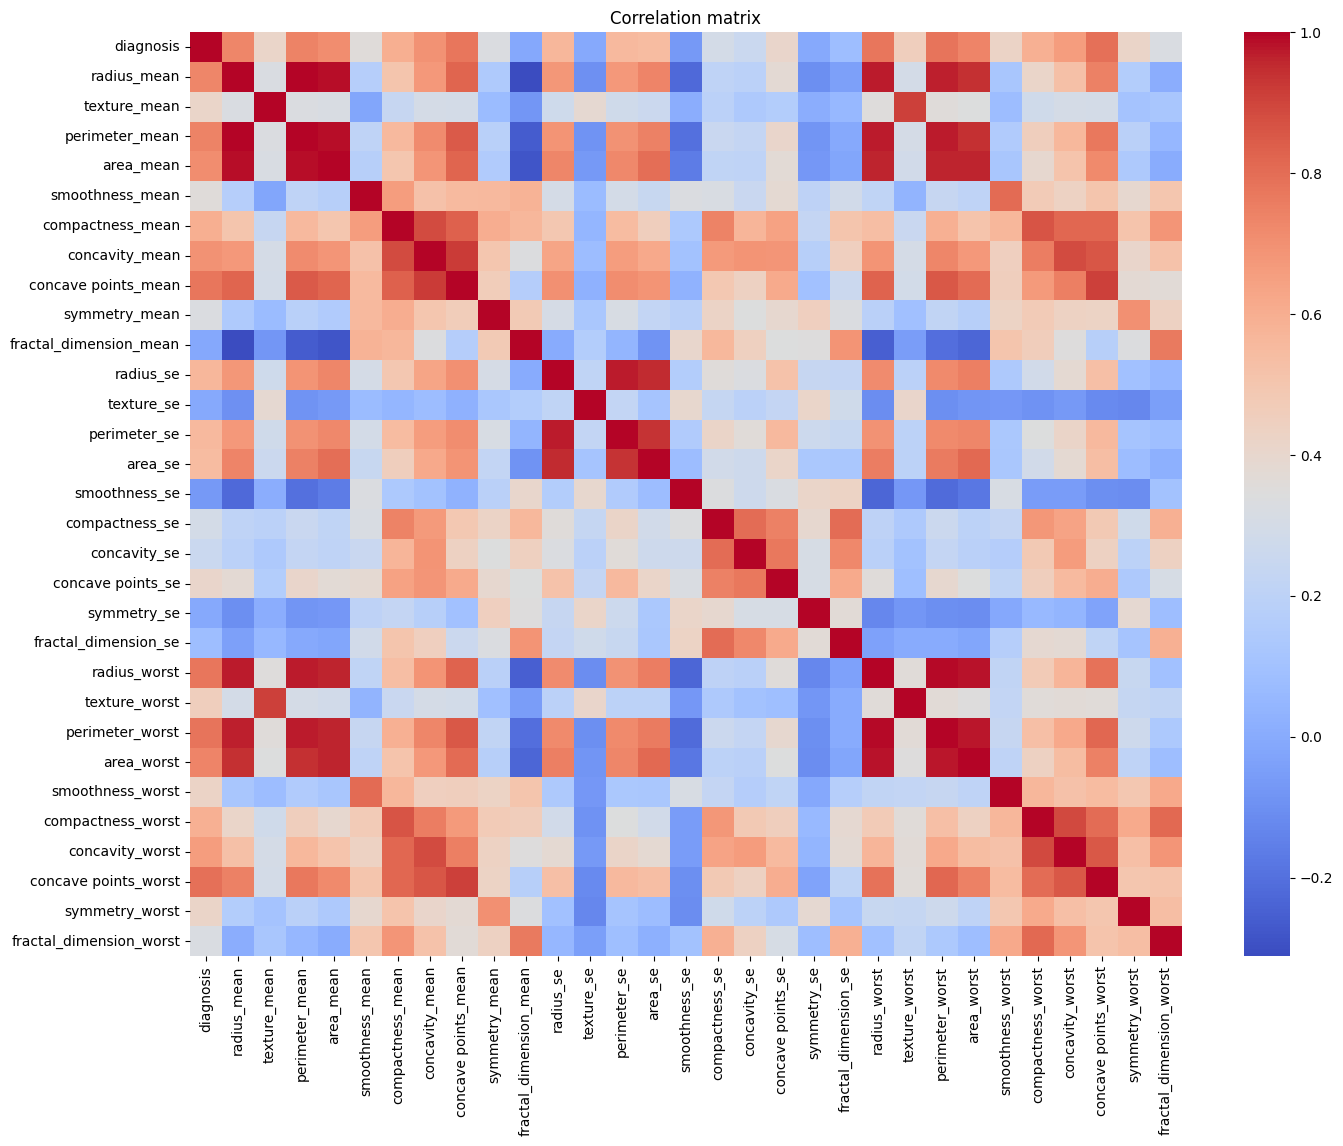

In [13]:
plt.figure(figsize=(16,12))

corr = df.corr()

sns.heatmap(corr, cmap="coolwarm")

plt.title("Correlation matrix")
plt.show()

### Анализ корреляций признаков

По heatmap видно, что в датасете присутствуют сильно скоррелированные признаки.

Наиболее сильная корреляция наблюдается между следующими признаками:

1. radius_mean, perimeter_mean и area_mean - признаки, характеризующие размер опухоли.
2. radius_worst, perimeter_worst и area_worst - аналогичные показатели для худших значений.
3. concavity_mean, concave points_mean и compactness_mean - признаки, описывающие форму опухоли.

Высокая корреляция между этими признаками объясняется тем, что они описывают схожие геометрические характеристики опухоли.

## Scatterplot

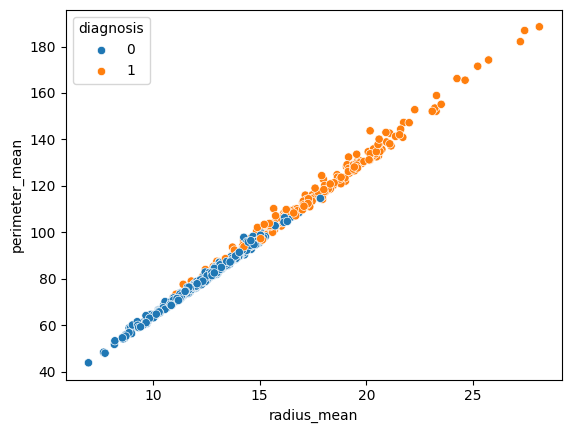

In [14]:
sns.scatterplot(data=df, x="radius_mean", y="perimeter_mean", hue="diagnosis")
plt.show()

### Анализ scatterplot

Scatterplot для признаков radius_mean и perimeter_mean показывает
выраженную линейную зависимость между этими переменными.

Точки на графике располагаются почти вдоль прямой линии,
что подтверждает сильную положительную корреляцию между признаками,
которую мы наблюдали на матрице корреляций.

Это объясняется тем, что оба признака описывают геометрические
характеристики опухоли: при увеличении радиуса увеличивается и периметр.

## Boxplots

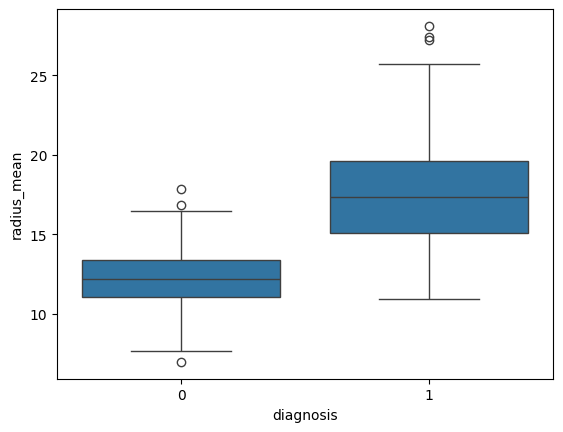

In [15]:
sns.boxplot(data=df, x="diagnosis", y="radius_mean")
plt.show()

### Анализ boxplot

По boxplot видно, что признак radius_mean хорошо разделяет
злокачественные и доброкачественные опухоли.

У злокачественных опухолей (diagnosis = 1) значения radius_mean
в среднем значительно выше, чем у доброкачественных (diagnosis = 0).

Это говорит о том, что данный признак может быть полезен
для построения модели классификации.

## Часть 2. Моделирование при помощи kNN

### Разделение данных на train и test

In [16]:
X = df.drop("diagnosis", axis=1)
y = df["diagnosis"]

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42
)

In [18]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((398, 30), (171, 30), (398,), (171,))

### Стандартизация признаков

Стандартизация особенно важна для алгоритма kNN,
так как он использует расстояния между объектами.
Если признаки имеют разные масштабы, признаки с большими значениями
будут сильнее влиять на результат классификации.

In [19]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [20]:
X_train_scaled[:5]

array([[-0.12348985, -0.29680142, -0.17050713, -0.20861569, -1.2016799 ,
        -0.7731696 , -0.76231194, -0.93324109, -1.22994935, -0.94816603,
        -0.53359339, -0.86028757, -0.61678096, -0.39177533, -1.35556152,
        -0.52503193, -0.4817033 , -0.97940018, -0.88459317, -0.68548672,
        -0.19761978, -0.5067476 , -0.30791001, -0.27357592, -1.50742388,
        -0.44926047, -0.57223884, -0.84082156, -0.8563616 , -0.76574773],
       [-0.22826757, -0.65795149, -0.25377521, -0.2965028 , -1.80463697,
        -0.58761605, -0.09198533, -0.54268359, -1.41998468, -0.61249143,
        -0.83040055, -0.12266723, -0.78254381, -0.53126109, -0.36490698,
         0.40861926,  0.57668457, -0.2482875 , -1.03572382,  0.10768859,
        -0.42291745, -0.45849468, -0.4652873 , -0.43812681, -1.27301714,
         0.02704209,  0.31804488, -0.37706655, -1.3415819 , -0.41480748],
       [ 0.14553402, -1.23056444,  0.24583328, -0.01024193,  0.5191843 ,
         1.57000613,  0.73231958,  0.38658307,  1

### Базовая модель kNN

In [21]:
knn = KNeighborsClassifier()

knn.fit(X_train_scaled, y_train)

y_pred = knn.predict(X_test_scaled)

### Метрики качества модели

In [22]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))

Accuracy: 0.9590643274853801
Precision: 0.9516129032258065
Recall: 0.9365079365079365
F1-score: 0.944


#### Анализ метрик качества модели

Базовая модель kNN показывает высокое качество классификации.

Accuracy ≈ 0.96 означает, что модель правильно классифицирует
около 96% наблюдений.

Высокие значения precision и recall показывают,
что модель хорошо определяет злокачественные опухоли
и при этом редко ошибается.

F1-score ≈ 0.94 подтверждает хороший баланс между
точностью и полнотой классификации.

Таким образом, даже базовая модель kNN демонстрирует
высокую эффективность для задачи классификации
злокачественных и доброкачественных опухолей.

### ROC-кривая

In [23]:
y_prob = knn.predict_proba(X_test_scaled)[:, 1]

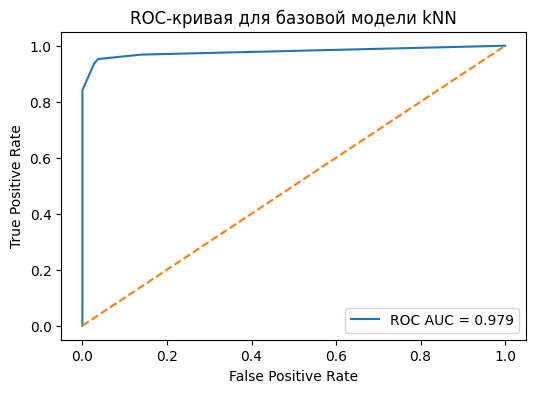

In [24]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f"ROC AUC = {roc_auc_score(y_test, y_prob):.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-кривая для базовой модели kNN")
plt.legend()
plt.show()

In [25]:
roc_auc = roc_auc_score(y_test, y_prob)
print("ROC-AUC:", roc_auc)

ROC-AUC: 0.9786890064667844


### Анализ ROC-кривой

ROC-кривая показывает способность модели различать
злокачественные и доброкачественные опухоли.

Площадь под ROC-кривой (ROC-AUC) составила примерно 0.979,
что говорит о высоком качестве модели.

Значение ROC-AUC, близкое к 1, означает, что модель хорошо
разделяет классы и с высокой вероятностью правильно
классифицирует наблюдения.

Таким образом, базовая модель kNN демонстрирует
очень хорошие результаты для данной задачи классификации.

## Подбор числа соседей с помощью кросс-валидации

Теперь подберем оптимальное значение параметра n_neighbors
с помощью кросс-валидации и сравним результаты с базовой моделью.

In [26]:
param_grid = {
    "n_neighbors": range(1, 21)
}

grid = GridSearchCV(
    KNeighborsClassifier(),
    param_grid=param_grid,
    cv=5,
    scoring="accuracy"
)

grid.fit(X_train_scaled, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KNeighborsClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'n_neighbors': range(1, 21)}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candidate param

In [27]:
grid.best_params_

{'n_neighbors': 3}

In [28]:
best_knn = grid.best_estimator_

## Повторная оценка

In [29]:
y_pred_best = best_knn.predict(X_test_scaled)

In [30]:
print("Accuracy:", accuracy_score(y_test, y_pred_best))
print("Precision:", precision_score(y_test, y_pred_best))
print("Recall:", recall_score(y_test, y_pred_best))
print("F1-score:", f1_score(y_test, y_pred_best))

Accuracy: 0.9590643274853801
Precision: 0.9516129032258065
Recall: 0.9365079365079365
F1-score: 0.944


In [31]:
y_prob_best = best_knn.predict_proba(X_test_scaled)[:, 1]

roc_auc_best = roc_auc_score(y_test, y_prob_best)
print("ROC-AUC:", roc_auc_best)

ROC-AUC: 0.9763374485596708


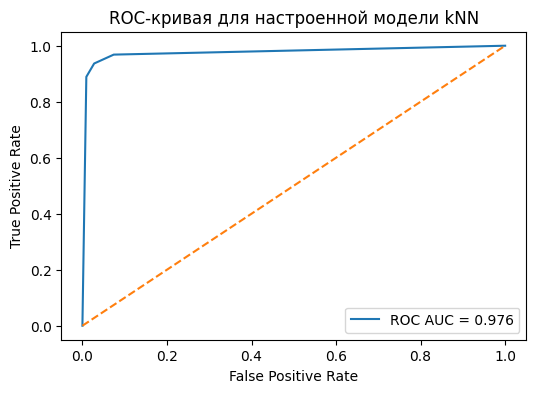

In [32]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob_best)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f"ROC AUC = {roc_auc_best:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-кривая для настроенной модели kNN")
plt.legend()
plt.show()

### Сравнение результатов

После подбора параметра числа соседей с помощью GridSearchCV
оптимальное значение оказалось равно n_neighbors = 3.

Однако при повторной оценке модели значения метрик практически
не изменились по сравнению с базовой моделью.

Accuracy, Precision, Recall и F1-score остались на том же уровне,
а значение ROC-AUC незначительно уменьшилось.

Это говорит о том, что базовая модель kNN уже показывала
очень хорошее качество на данном датасете, и дополнительная
настройка параметра числа соседей не привела к существенному
улучшению качества модели.